<a href="https://colab.research.google.com/github/Areeba391391/housing-price-prediction/blob/main/housing_price_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Columns: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Missing Values:
 MedInc                      0
HouseAge                    0
AveRooms                    0
AveBedrms                   0
Population                  0
AveOccup                    0
Latitude                    0
Longitude               

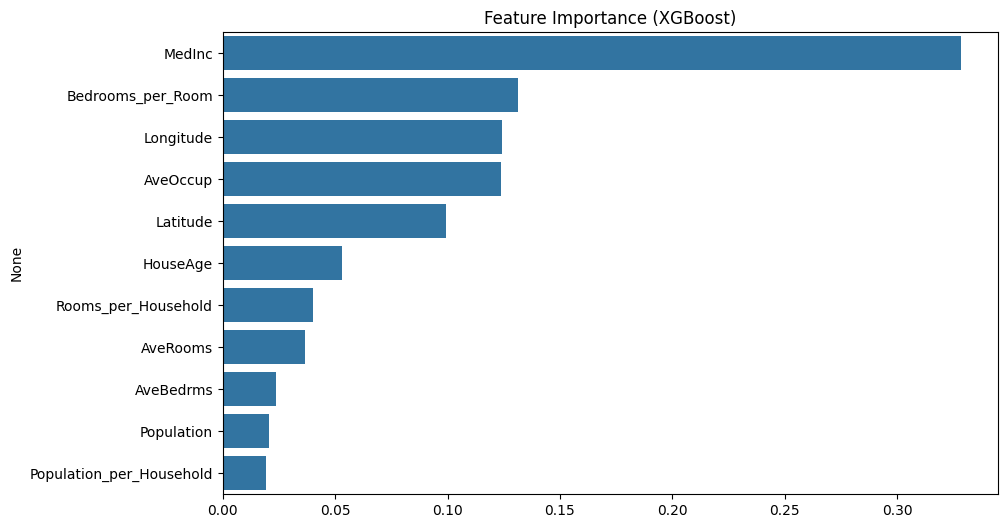

'\nparam_grid = {\n    \'n_estimators\': [100, 300, 500],\n    \'max_depth\': [10, 20, 30],\n    \'min_samples_split\': [2, 5, 10]\n}\ngrid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring=\'r2\', n_jobs=-1)\ngrid_search.fit(X_train, y_train)\nprint("Best RF Params:", grid_search.best_params_)\nbest_rf = grid_search.best_estimator_\ny_pred_best_rf = best_rf.predict(X_test)\nprint("Tuned RF R2:", r2_score(y_test, y_pred_best_rf))\n'

In [1]:
# Advanced Housing Price Prediction - California Dataset

# Import libraries
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------
# 1. Load dataset
# -----------------------
california = fetch_california_housing(as_frame=True)
df = california.frame  # pandas DataFrame

# Quick overview
print("Columns:", df.columns.tolist())
print(df.head())

# -----------------------
# 2. Feature Engineering
# -----------------------
# Create new features if helpful
df['Rooms_per_Household'] = df['AveRooms'] / df['HouseAge']
df['Bedrooms_per_Room'] = df['AveBedrms'] / df['AveRooms']
df['Population_per_Household'] = df['Population'] / df['HouseAge']

# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

# -----------------------
# 3. Split Features & Target
# -----------------------
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------
# 4. Scale Features
# -----------------------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------
# 5. Train Random Forest
# -----------------------
rf_model = RandomForestRegressor(n_estimators=300, max_depth=20, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print(f"\nRandom Forest -> MSE: {mse_rf:.4f}, R2: {r2_rf:.4f}")

# -----------------------
# 6. Train XGBoost (more advanced)
# -----------------------
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train_scaled, y_train)
y_pred_xgb = xgb_model.predict(X_test_scaled)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)
print(f"XGBoost -> MSE: {mse_xgb:.4f}, R2: {r2_xgb:.4f}")

# -----------------------
# 7. Feature Importance
# -----------------------
importance = pd.Series(xgb_model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=importance.values, y=importance.index)
plt.title("Feature Importance (XGBoost)")
plt.show()

# -----------------------
# 8. Optional: Hyperparameter Tuning (Random Forest)
# -----------------------
# Uncomment below if you want to tune hyperparameters
"""
param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}
grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)
print("Best RF Params:", grid_search.best_params_)
best_rf = grid_search.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)
print("Tuned RF R2:", r2_score(y_test, y_pred_best_rf))
"""